In [ ]:
# Import libraries
import numpy as np
import pandas as pd

# Modeling & metrics
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Utilities & plots
import matplotlib.pyplot as plt
from pathlib import Path
import sys, platform


In [ ]:
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
print(df.shape)
df.info()

(200, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
# Check for missing values
print("Missing values before handling missing values:")
print(df.isnull().sum())

# If there are any missing values (no missing values in this dataset), fill:
# Numeric -> median, Categorical -> mode
for col in df.columns:
    if df[col].dtype.kind in "biufc":      # numeric
        df[col] = df[col].fillna(df[col].median())
    else:                                   # categorical
        df[col] = df[col].fillna(df[col].mode()[0])

# Missing values after handling missing values
print("\nMissing values AFTER:")
print(df.isnull().sum())

Missing values before handling missing values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Missing values AFTER:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Identify categorical columns
categorical_cols = df.select_dtypes(exclude=[np.number]).columns
print("Categorical columns:", list(categorical_cols))

# Encode
le = LabelEncoder()
for c in categorical_cols:
    df[c] = le.fit_transform(df[c])

print("\nHead AFTER Label Encoding:")
print(df.head())

Categorical columns: ['Gender']

Head AFTER Label Encoding:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1       1   19                  15                      39
1           2       1   21                  15                      81
2           3       0   20                  16                       6
3           4       0   23                  16                      77
4           5       0   31                  17                      40


In [ ]:
# Cluster on three features (Age, Annual Income and Spending Score)
feature_cols = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X = df[feature_cols].copy()
print("Selected features:", feature_cols)
print(X.head())

Selected features: ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
   Age  Annual Income (k$)  Spending Score (1-100)
0   19                  15                      39
1   21                  15                      81
2   20                  16                       6
3   23                  16                      77
4   31                  17                      40


In [ ]:
# Manual Min–Max normalization (Feature Scaling)
X_norm = X.copy()
for col in feature_cols:
    col_min = X_norm[col].min()
    col_max = X_norm[col].max()
    X_norm[col] = (X_norm[col] - col_min) / (col_max - col_min)

print(X_norm.describe())

              Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000          200.000000              200.000000
mean     0.400962            0.373443                0.502041
std      0.268635            0.215285                0.263505
min      0.000000            0.000000                0.000000
25%      0.206731            0.217213                0.344388
50%      0.346154            0.381148                0.500000
75%      0.596154            0.516393                0.734694
max      1.000000            1.000000                1.000000


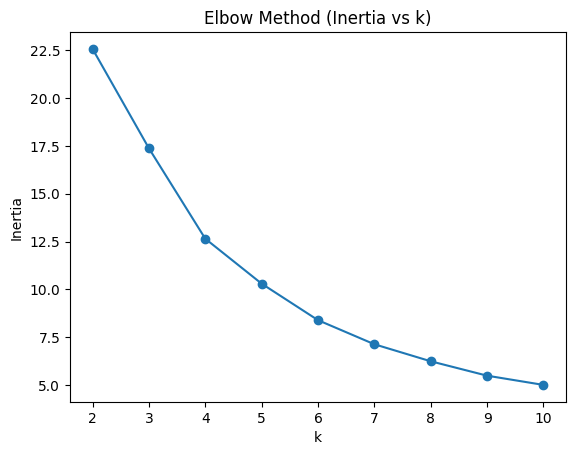

In [ ]:
inertias = []
k_values = range(2, 11)
for k in k_values:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_norm)
    inertias.append(km.inertia_)

plt.figure()
plt.plot(list(k_values), inertias, marker='o')
plt.title("Elbow Method (Inertia vs k)")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.xticks(list(k_values))
plt.show()

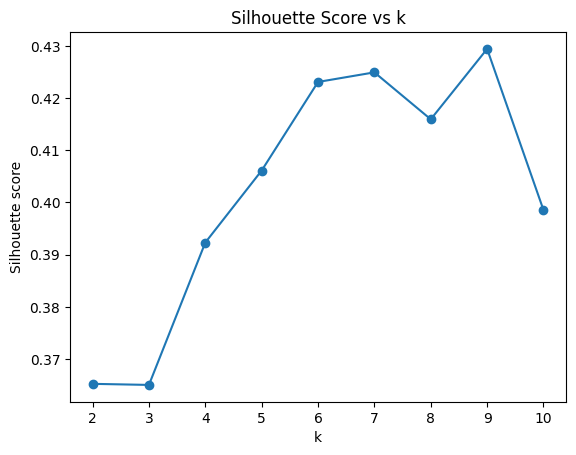

Best k by silhouette: 5


In [ ]:
from sklearn.metrics import silhouette_score

sil_scores = []
for k in k_values:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X_norm)
    sil = silhouette_score(X_norm, labels)
    sil_scores.append(sil)

plt.figure()
plt.plot(list(k_values), sil_scores, marker='o')
plt.title("Silhouette Score vs k")
plt.xlabel("k")
plt.ylabel("Silhouette score")
plt.xticks(list(k_values))
plt.show()

# Pick best by silhouette (you may also choose k by elbow + business sense)
best_k = int(k_values[np.argmax(sil_scores)])
print("Best k by silhouette:", best_k)

In [ ]:
K = 5
kmeans = KMeans(n_clusters=K, init='k-means++', n_init=10, random_state=42)
cluster_labels = kmeans.fit_predict(X_norm)

df_clusters = df.copy()
df_clusters['Cluster'] = cluster_labels
print(df_clusters[['Gender','Age','Annual Income (k$)','Spending Score (1-100)','Cluster']].head())

   Gender  Age  Annual Income (k$)  Spending Score (1-100)  Cluster
0       1   19                  15                      39        1
1       1   21                  15                      81        2
2       0   20                  16                       6        1
3       0   23                  16                      77        2
4       0   31                  17                      40        1


In [ ]:
from sklearn.metrics import davies_bouldin_score

sil = silhouette_score(X_norm, cluster_labels)
dbi = davies_bouldin_score(X_norm, cluster_labels)
print(f"Silhouette score (k={K}): {sil:.3f}")
print(f"Davies–Bouldin index (k={K}): {dbi:.3f}")

Silhouette score (k=5): 0.406
Davies–Bouldin index (k=5): 0.880


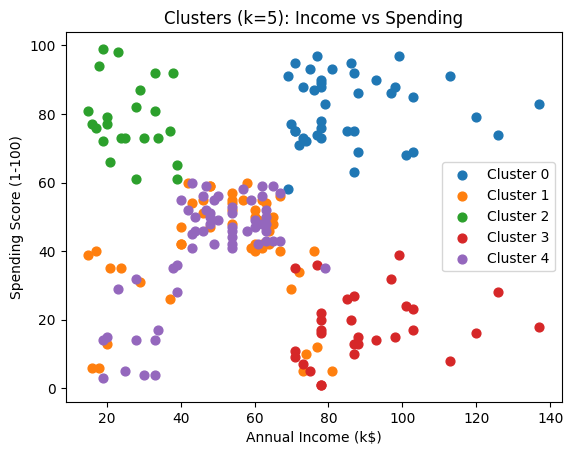

In [ ]:
colors = ['tab:blue','tab:orange','tab:green','tab:red','tab:purple','tab:brown','tab:pink','tab:gray','tab:olive','tab:cyan']

plt.figure()
for c in range(K):
    idx = (df_clusters['Cluster'] == c)
    plt.scatter(df_clusters.loc[idx, 'Annual Income (k$)'],
                df_clusters.loc[idx, 'Spending Score (1-100)'],
                s=40, label=f"Cluster {c}", color=colors[c % len(colors)])
plt.title(f"Clusters (k={K}): Income vs Spending")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()
plt.show()

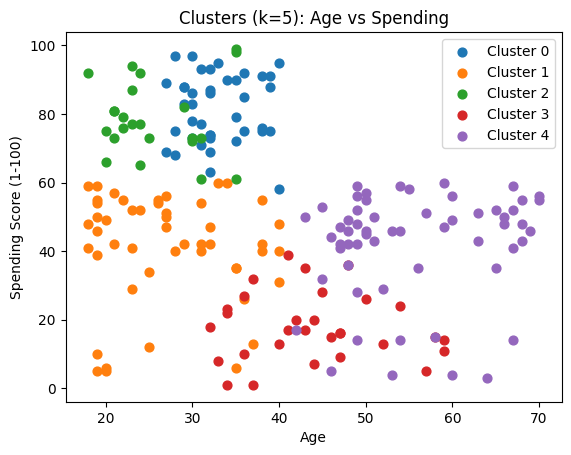

In [ ]:
plt.figure()
for c in range(K):
    idx = (df_clusters['Cluster'] == c)
    plt.scatter(df_clusters.loc[idx, 'Age'],
                df_clusters.loc[idx, 'Spending Score (1-100)'],
                s=40, label=f"Cluster {c}", color=colors[c % len(colors)])
plt.title(f"Clusters (k={K}): Age vs Spending")
plt.xlabel("Age")
plt.ylabel("Spending Score (1-100)")
plt.legend()
plt.show()

In [ ]:
profile = df_clusters.groupby('Cluster')[['Age','Annual Income (k$)','Spending Score (1-100)']].mean().round(1)
profile['Count'] = df_clusters.groupby('Cluster').size()
print(profile)

          Age  Annual Income (k$)  Spending Score (1-100)  Count
Cluster                                                         
0        32.9                86.1                    81.5     40
1        27.1                52.0                    41.0     49
2        25.5                26.3                    78.6     23
3        44.0                90.1                    17.9     30
4        55.6                48.5                    41.8     58


In [ ]:
# If 'Gender' was encoded 0/1, map back for readability (0=Female, 1=Male)
gender_map = {0:'Female', 1:'Male'}
gender_series = df_clusters['Gender'].map(gender_map) if df_clusters['Gender'].dtype != 'O' else df_clusters['Gender']

gender_mix = pd.crosstab(df_clusters['Cluster'], gender_series, normalize='index').mul(100).round(1)
print(gender_mix)

Gender   Female  Male
Cluster              
0          55.0  45.0
1          59.2  40.8
2          60.9  39.1
3          46.7  53.3
4          56.9  43.1
